**Parameters to fit:** <br>
beta = 0.5<br>
deltaG1_0 = -10e3<br>
<br>
**Error parameters:** <br>
noise_fraction = 0.03<br>
<br> 
**Reference values:** <br>
E1_0 = 0 <br>
E2_0 = 0 <br>
<br>
**BEP relation:** <br>
Gact2_0 = 100e3 + 0.5 * deltaG1_0<br>
Using Bayesian Optimization to calculate appropriate values for deltaG1_0 and beta. 

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import xarray as xr
import matplotlib.pyplot as plt

# 1. LOAD DATA
data = np.load("fake_data1.npz")
E_obs = data["E"]             
alpha_obs = data["alpha"] 
delta_obs = data["delta"] 

# 2. DEFINE GRID STEPS (For calculating slopes explicitly)
dE = E_obs[1] - E_obs[0]               # Voltage step size
concs = np.array([1e-3, 1e-2, 1e-1, 1.0])
d_ln_c = np.diff(np.log(concs))        # Concentration step size

R, T, F = 8.314, 298.15, 96485.3
kb, h = 1.3806e-23, 6.626e-34

print("✅ Data Loaded & Grid Ready")

✅ Data Loaded & Grid Ready


In [2]:
def build_model(name, rate_equation_function):
    """
    A factory that builds a PyMC model given a specific rate equation.
    Standardizes Alpha/Delta calculation and Error handling.
    """
    with pm.Model(name=name) as model:
        
        # --- A. SHARED PRIORS (The "Knobs") ---
        deltaG1_0 = pm.Normal("deltaG1_0", mu=-10000, sigma=5000)
        sigma_base = pm.HalfNormal("sigma_base", 0.05)
        sigma_rel  = pm.HalfNormal("sigma_rel", 0.1)

        # --- B. CALCULATE RATE (The "Physics") ---
        log_rate, theta = rate_equation_function(deltaG1_0, E_obs, concs)

        # --- C. EXPLICIT DERIVATIVES (The "Uniformity") ---
        # 1. Alpha = - (RT/F) * d(ln Rate) / dE
        # We take difference along axis 0 (Voltage)
        diff_E = log_rate[1:, :] - log_rate[:-1, :] 
        mu_alpha = -(R * T / F) * (diff_E / dE)
        # 2. Delta = d(ln Rate) / d(ln C)
        # We take difference along axis 1 (Concentration)
        diff_C = log_rate[:, 1:] - log_rate[:, :-1]
        mu_delta = diff_C / d_ln_c[None, :]

        # --- D. LIKELIHOOD (The "Score") ---
        # Note: We slice observations [1:] or [:-1] because differentiation 
        # loses 1 data point of shape.
        # Alpha Score
        sig_a = sigma_base + sigma_rel * pm.math.abs(mu_alpha)
        ll_alpha = pm.StudentT("obs_alpha", nu=4, mu=mu_alpha.flatten(), 
                               sigma=sig_a.flatten(), 
                               observed=alpha_obs[1:, :].flatten())
        # Delta Score
        sig_d = sigma_base + sigma_rel * pm.math.abs(mu_delta)
        ll_delta = pm.StudentT("obs_delta", nu=4, mu=mu_delta.flatten(), 
                               sigma=sig_d.flatten(), 
                               observed=delta_obs.flatten())
        
        # --- E. COMBINE SCORES ---
        pm.Deterministic("total_log_lik", ll_alpha.sum() + ll_delta.sum())
        
    return model

🤖 Fitting Volmer-Heyrovsky (Correct Model)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [VH::deltaG1_0, VH::sigma_base, VH::sigma_rel, VH::beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


Output()


📊 --- VH RESULTS SUMMARY ---
                    mean       sd     hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
VH::beta           0.502    0.002      0.498     0.507      0.000    0.000   
VH::deltaG1_0  -9960.515  104.196 -10161.376 -9769.312      1.622    1.686   
VH::sigma_base     0.033    0.001      0.031     0.036      0.000    0.000   
VH::sigma_rel      0.000    0.000      0.000     0.001      0.000    0.000   

                ess_bulk  ess_tail  r_hat  
VH::beta          3414.0    2947.0    1.0  
VH::deltaG1_0     4135.0    3032.0    1.0  
VH::sigma_base    4094.0    2889.0    1.0  
VH::sigma_rel     3059.0    1816.0    1.0  

📈 Plotting Trace (Sanity Check)...


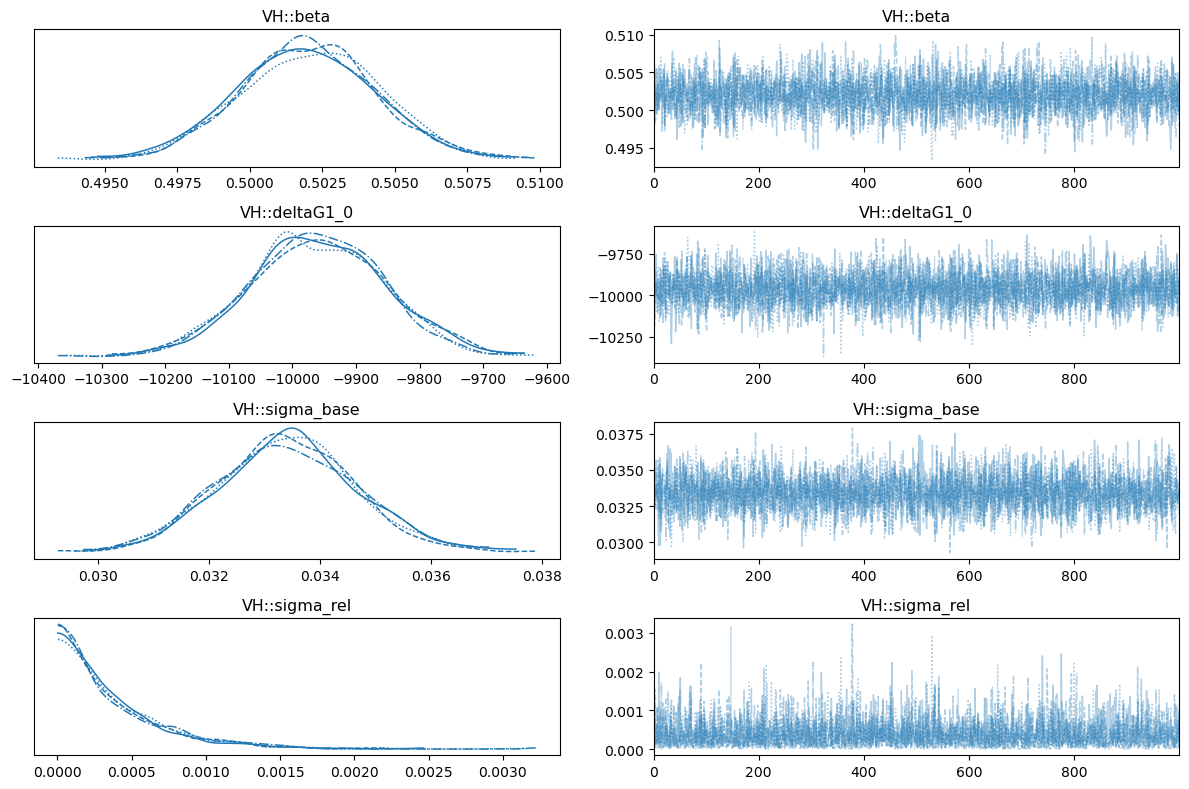


🔔 Plotting Posteriors (The Answers)...


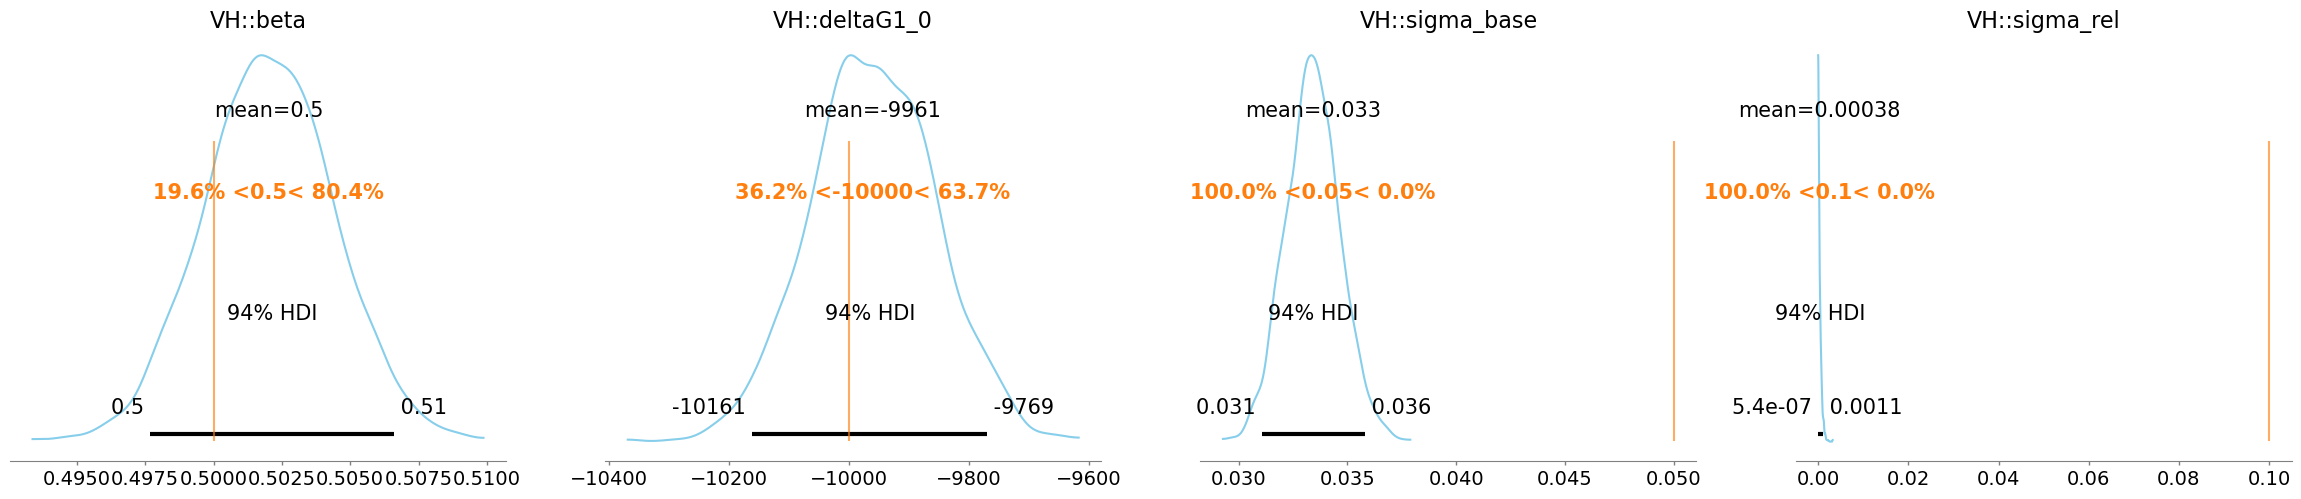

In [3]:
# --- STEP 1: DEFINE PHYSICS ---
def vh_physics(deltaG1_0, E, C):
    # Unique Parameter: Beta
    beta = pm.Normal("beta", 0.5, 0.1)
    
    # Physics
    dG1 = deltaG1_0 + F * E[:, None]
    K1 = pm.math.exp(-dG1 / (R * T))
    
    Gact2 = (100e3 + 0.5*deltaG1_0) + beta * F * E[:, None]
    k2 = (kb * T / h) * pm.math.exp(-Gact2 / (R * T))
    
    # Rate Law
    C_grid = C[None, :]
    theta = (K1 * C_grid) / (1 + K1 * C_grid)
    rate = k2 * C_grid * theta 
    
    return pm.math.log(rate), theta

# --- STEP 2: FIT MODEL ---
print("🤖 Fitting Volmer-Heyrovsky (Correct Model)...")
model_vh = build_model("VH", vh_physics)
with model_vh:
    idata_vh = pm.sample(1000, target_accept=0.95, progressbar=True)
    # Calculate scores immediately so we don't forget
    pm.compute_log_likelihood(idata_vh)

# --- STEP 3: IMMEDIATE RESULTS ---
print("\n📊 --- VH RESULTS SUMMARY ---")
# Summary Table (R_hat should be < 1.01)
print(az.summary(idata_vh, var_names=["VH::beta", "VH::deltaG1_0", "VH::sigma_base", "VH::sigma_rel"]))

print("\n📈 Plotting Trace (Sanity Check)...")
az.plot_trace(idata_vh, var_names=["VH::beta", "VH::deltaG1_0", "VH::sigma_base", "VH::sigma_rel"])
plt.tight_layout()
plt.show()

print("\n🔔 Plotting Posteriors (The Answers)...")
az.plot_posterior(
    idata_vh, 
    var_names=["VH::beta", "VH::deltaG1_0", "VH::sigma_base", "VH::sigma_rel"],
    ref_val=[0.5, -10000, 0.05, 0.1], # Green lines for "Truth"
    color="skyblue"
)
plt.show()

🤖 Fitting Volmer-Tafel (Incorrect Model)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [VT::deltaG1_0, VT::sigma_base, VT::sigma_rel, VT::k_tafel]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.


Output()


📊 --- VT RESULTS SUMMARY ---
                    mean        sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
VT::k_tafel        0.000     0.000     0.000     0.000      0.000    0.000   
VT::deltaG1_0  -3540.580  1061.522 -5519.943 -1540.607     19.503   17.293   
VT::sigma_base     0.605     0.016     0.574     0.634      0.000    0.000   
VT::sigma_rel      0.024     0.021     0.000     0.063      0.000    0.000   

                ess_bulk  ess_tail  r_hat  
VT::k_tafel       3101.0    2545.0    1.0  
VT::deltaG1_0     2968.0    2568.0    1.0  
VT::sigma_base    3104.0    2023.0    1.0  
VT::sigma_rel     2214.0    1541.0    1.0  

📈 Plotting Trace (Sanity Check)...


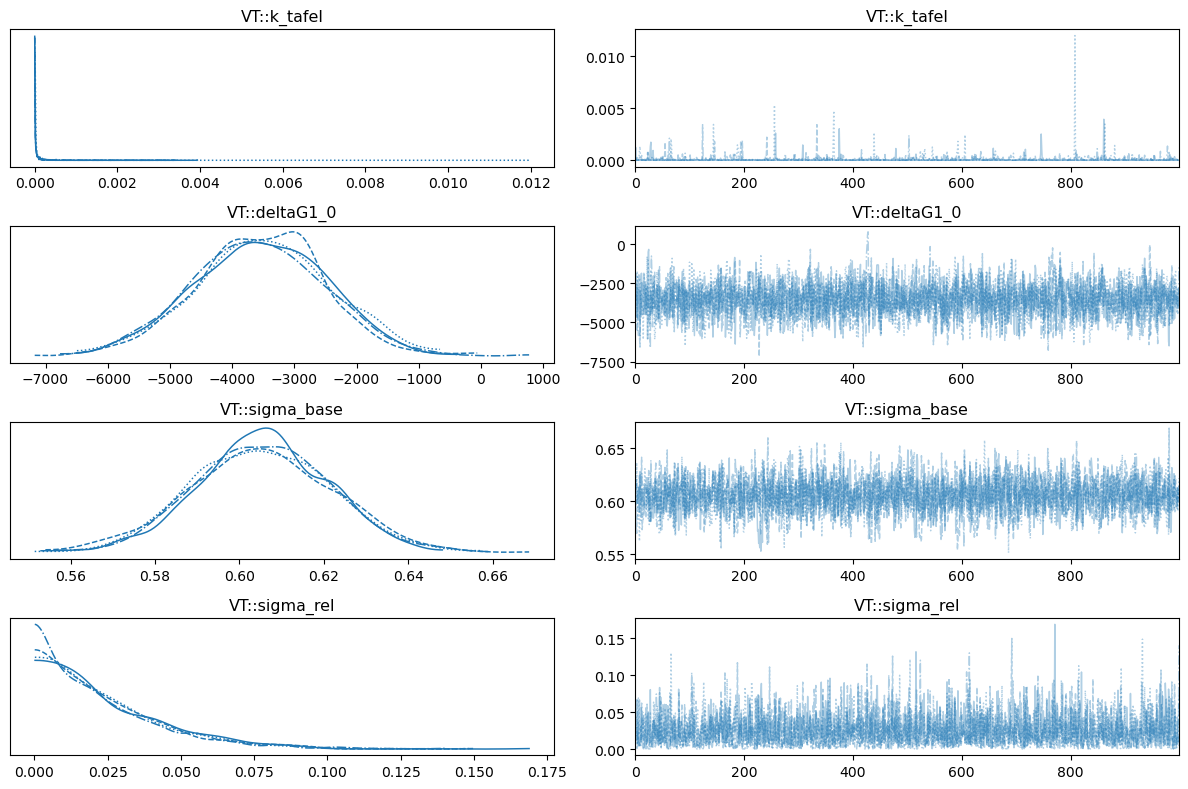


🔔 Plotting Posteriors (The Answers)...


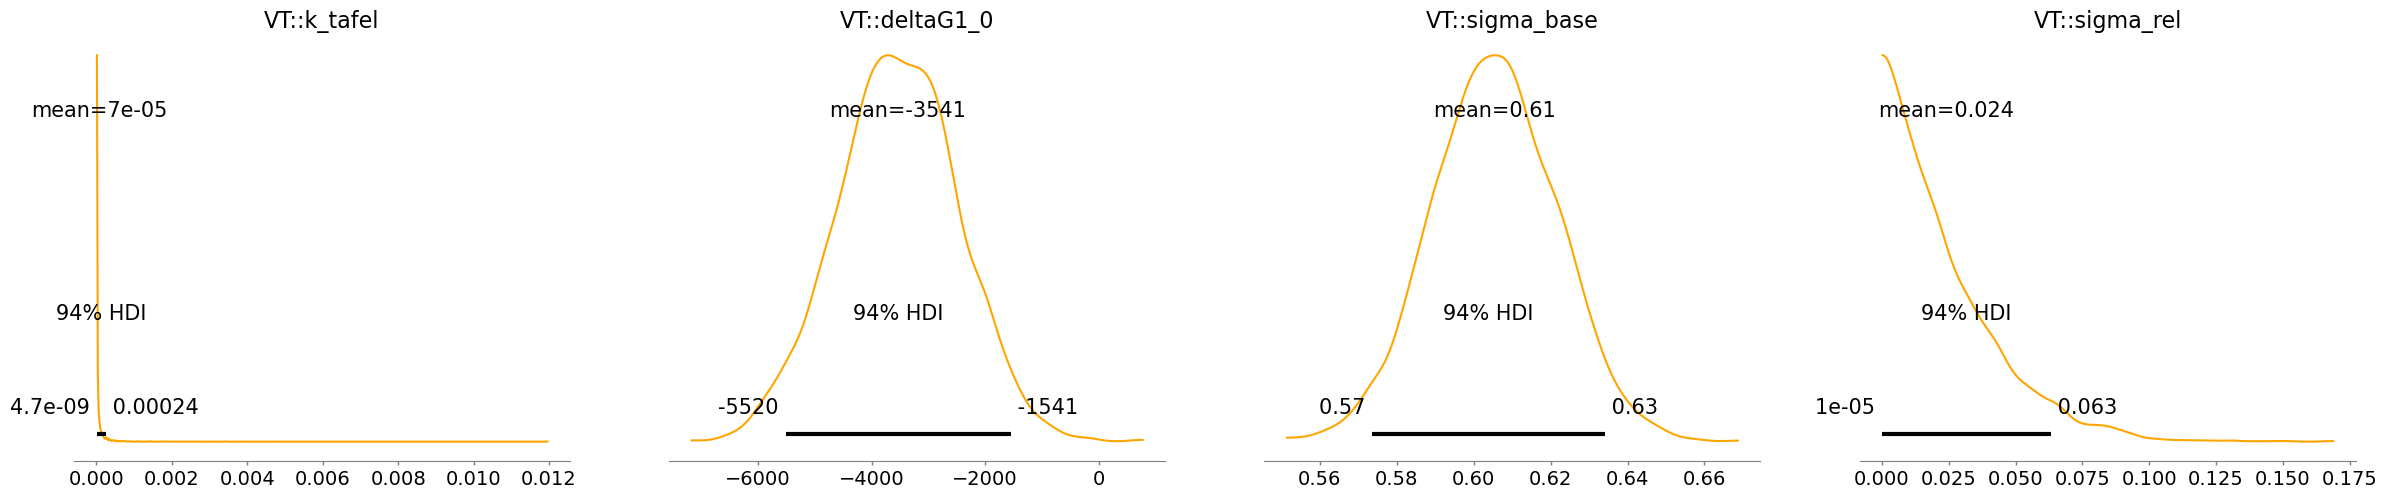

In [4]:
# --- STEP 1: DEFINE PHYSICS ---
def vt_physics(deltaG1_0, E, C):
    # Unique Parameter: Rate Constant (LogNormal)
    k_tafel = pm.LogNormal("k_tafel", mu=np.log(1e-5), sigma=2)
    
    # Physics
    dG1 = deltaG1_0 + F * E[:, None]
    K1 = pm.math.exp(-dG1 / (R * T))
    
    # Rate Law
    C_grid = C[None, :]
    theta = (K1 * C_grid) / (1 + K1 * C_grid)
    rate = k_tafel * (theta ** 2)
    
    return pm.math.log(rate), theta

# --- STEP 2: FIT MODEL ---
print("🤖 Fitting Volmer-Tafel (Incorrect Model)...")
model_vt = build_model("VT", vt_physics)
with model_vt:
    idata_vt = pm.sample(1000, target_accept=0.95, progressbar=True)
    pm.compute_log_likelihood(idata_vt)

# --- STEP 3: IMMEDIATE RESULTS ---
print("\n📊 --- VT RESULTS SUMMARY ---")
# Summary Table
print(az.summary(idata_vt, var_names=["VT::k_tafel", "VT::deltaG1_0", "VT::sigma_base", "VT::sigma_rel"]))

print("\n📈 Plotting Trace (Sanity Check)...")
az.plot_trace(idata_vt, var_names=["VT::k_tafel", "VT::deltaG1_0", "VT::sigma_base", "VT::sigma_rel"])
plt.tight_layout()
plt.show()

print("\n🔔 Plotting Posteriors (The Answers)...")
az.plot_posterior(
    idata_vt, 
    var_names=["VT::k_tafel", "VT::deltaG1_0", "VT::sigma_base", "VT::sigma_rel"],
    color="orange" # Different color to distinguish
)
plt.show()

In [6]:
import xarray as xr

def standardize_evidence(idata):
    """
    1. Finds the alpha/delta likelihoods regardless of model prefix (VH:: or VT::).
    2. Renames their specific dimensions (e.g., 'obs_alpha_dim_0') to a shared 'total_dim'.
    3. Concatenates them into one long 'obs_total' array for Arviz.
    """
    ll = idata.log_likelihood
    
    # A. Find the keys dynamically (Matches "VH::obs_alpha" or just "obs_alpha")
    # We look for any variable name that *ends with* the standard names
    key_alpha = [k for k in ll.data_vars if k.endswith("obs_alpha")][0]
    key_delta = [k for k in ll.data_vars if k.endswith("obs_delta")][0]
    
    print(f"   Found keys: {key_alpha} & {key_delta}")

    # B. Extract the DataArrays
    da_alpha = ll[key_alpha]
    da_delta = ll[key_delta]
    
    # C. Find the 'observation' dimension (The one that isn't 'chain' or 'draw')
    dim_alpha = [d for d in da_alpha.dims if d not in ("chain", "draw")][0]
    dim_delta = [d for d in da_delta.dims if d not in ("chain", "draw")][0]
    
    # D. Rename dimensions to allow merging
    da_alpha = da_alpha.rename({dim_alpha: "total_dim"})
    da_delta = da_delta.rename({dim_delta: "total_dim"})
    
    # E. Concatenate (Stick them end-to-end)
    # Result shape: (chain, draw, 700)
    combined = xr.concat([da_alpha, da_delta], dim="total_dim")
    
    # F. Save back
    ll["obs_total"] = combined
    return idata

# --- EXECUTE FIX ---
print("Standardizing Volmer-Heyrovsky...")
idata_vh = standardize_evidence(idata_vh)

print("Standardizing Volmer-Tafel...")
idata_vt = standardize_evidence(idata_vt)

print("✅ Evidence merged successfully.")

Standardizing Volmer-Heyrovsky...
   Found keys: VH::obs_alpha & VH::obs_delta
Standardizing Volmer-Tafel...
   Found keys: VT::obs_alpha & VT::obs_delta
✅ Evidence merged successfully.


Calculating Probabilities...

--- PROBABILITY (WEIGHT) ---
                  weight    elpd_diff
Volmer-Heyrovsky     1.0     0.000000
Volmer-Tafel         0.0  2028.983887


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

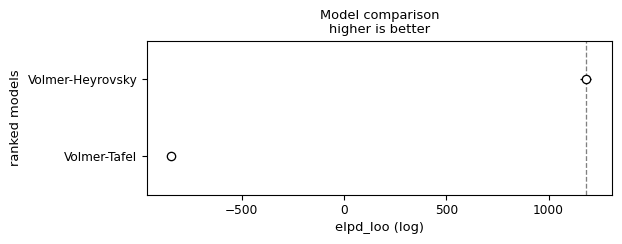

In [7]:
# --- BLOCK 7: MODEL COMPARISON (Fixed) ---
print("Calculating Probabilities...")

# 1. Run the Comparison
comp = az.compare({
    "Volmer-Heyrovsky": idata_vh, 
    "Volmer-Tafel": idata_vt
}, var_name="obs_total", ic="loo", method="stacking")

# 2. Print the Table
print("\n--- PROBABILITY (WEIGHT) ---")
# weight    : Probability this is the best model (0.0 to 1.0)
# elpd_diff : Distance from the best model (0.0 is best)
print(comp[["weight", "elpd_diff"]])

# 3. Visual Plot
az.plot_compare(comp)

--- 1. PARAMETER DISTRIBUTIONS (Volmer-Heyrovsky) ---


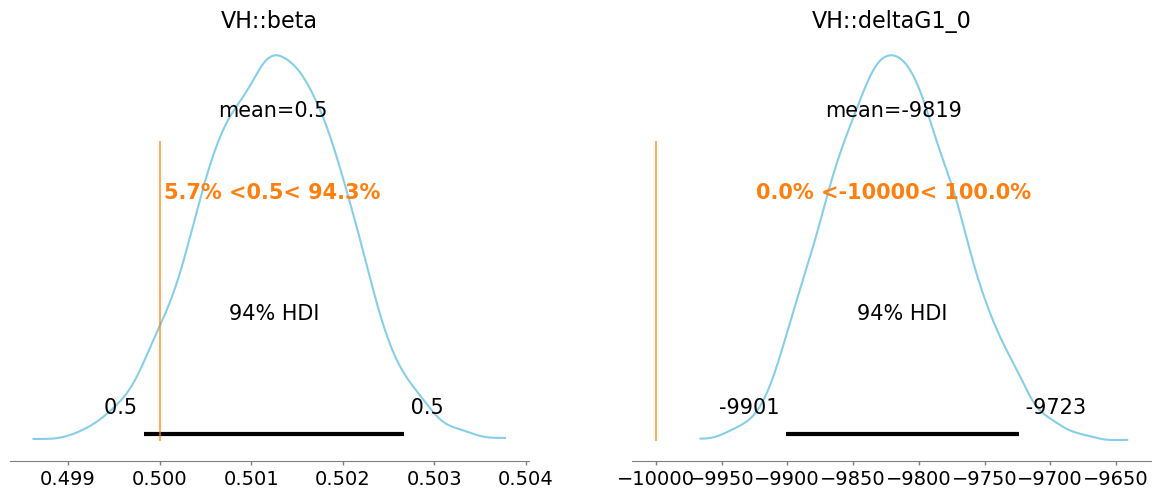


--- 2. PARAMETER CORRELATION (Banana Plot) ---


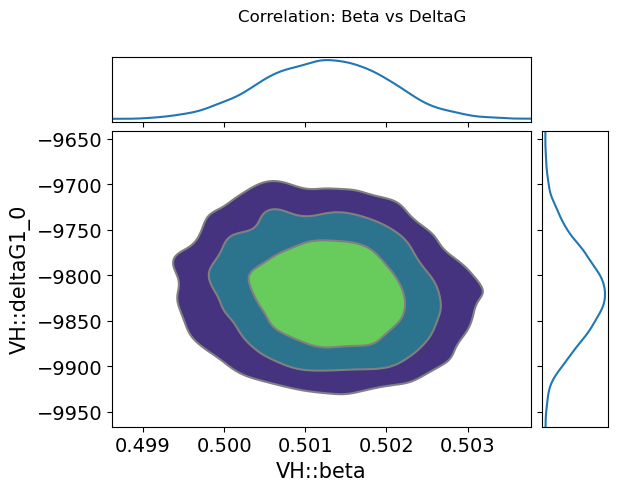

In [ ]:
import arviz as az
import matplotlib.pyplot as plt

print("--- 1. PARAMETER DISTRIBUTIONS (Volmer-Heyrovsky) ---")
# We explicitly ask for the variables using their "VH::" prefix
az.plot_posterior(
    idata_vh, 
    var_names=["VH::beta", "VH::deltaG1_0"], 
    ref_val=[0.5, -10000],  # The Truth (Green Line)
    color="skyblue"
)
plt.show()

print("\n--- 2. PARAMETER CORRELATION (Banana Plot) ---")
# This shows if Beta and DeltaG are "tangled" together
az.plot_pair(
    idata_vh, 
    var_names=["VH::beta", "VH::deltaG1_0"], 
    kind="kde", 
    marginals=True
)
plt.suptitle("Correlation: Beta vs DeltaG")
plt.show()

Drawing curves for VH...
Drawing curves for VT...


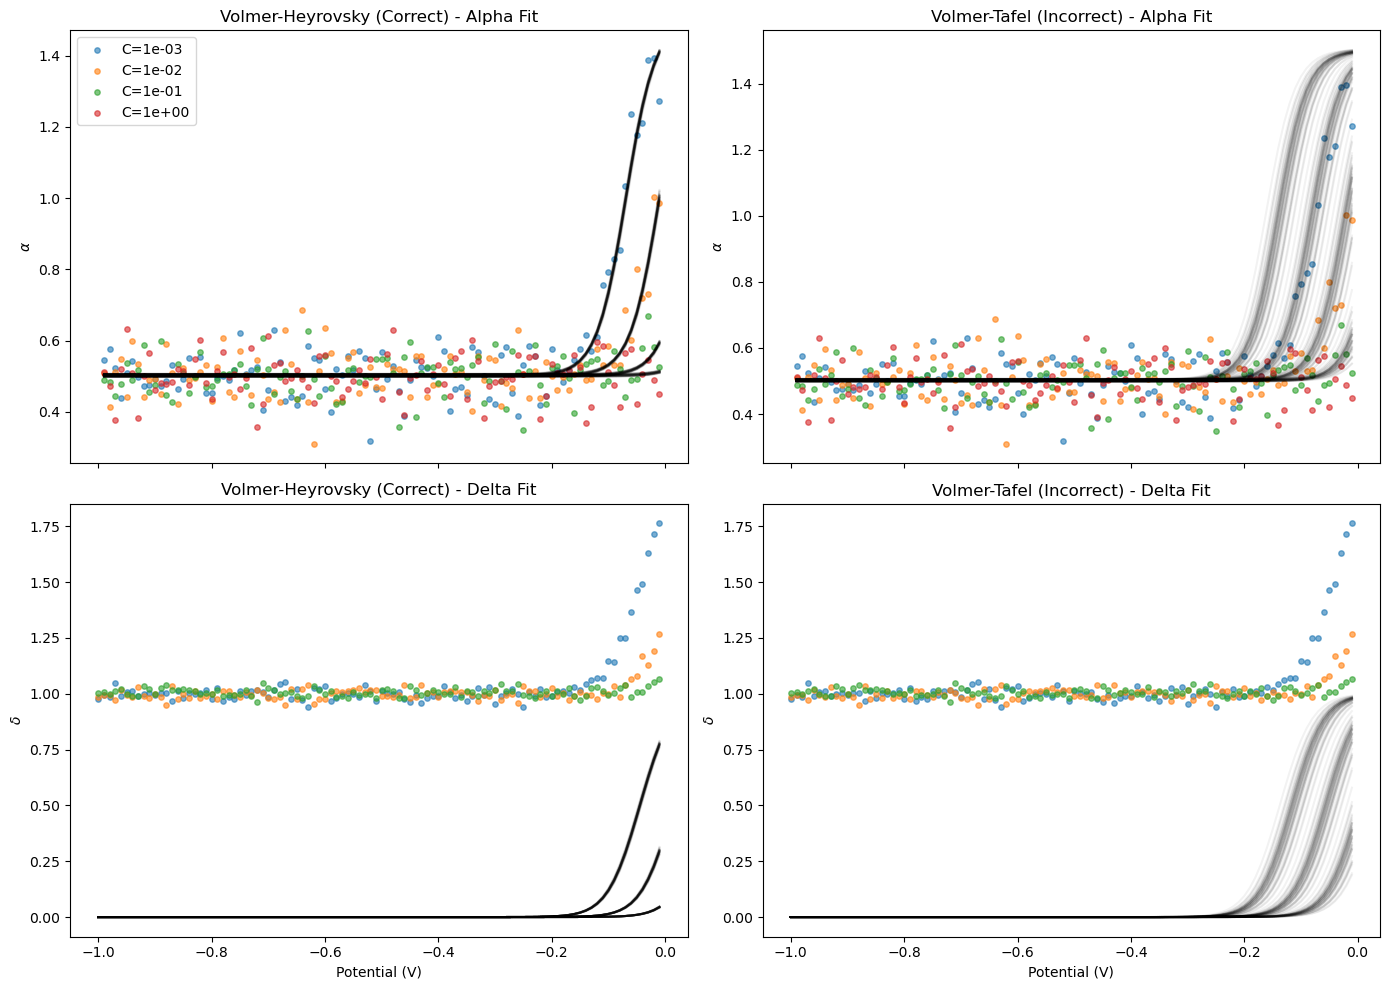

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- SETUP ---
n_samples = 50
rng = np.random.default_rng(42)

# Get the posteriors
post_vh = idata_vh.posterior
post_vt = idata_vt.posterior

# Pick random sample indices
total_samples = len(post_vh.draw) * len(post_vh.chain)
draw_idxs = rng.choice(total_samples, n_samples, replace=False)

# Setup Canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
titles = ["Volmer-Heyrovsky (Correct)", "Volmer-Tafel (Incorrect)"]

# --- LOOP OVER MODELS ---
for m_idx, code in enumerate(["VH", "VT"]):
    
    # Select the right posterior and prefix
    if code == "VH":
        post = post_vh
        prefix = "VH"
    else:
        post = post_vt
        prefix = "VT"

    # --- PLOT 1: ALPHA (Top Row) ---
    ax_alpha = axes[0, m_idx]
    ax_alpha.set_title(f"{titles[m_idx]} - Alpha Fit")
    ax_alpha.set_ylabel(r"$\alpha$")
    
    # Real Data (Drop first point to match slope calc)
    for i, c in enumerate(concs):
        ax_alpha.scatter(E_obs[1:], alpha_obs[1:, i], label=f"C={c:.0e}", s=15, alpha=0.6)

    # --- PLOT 2: DELTA (Bottom Row) ---
    ax_delta = axes[1, m_idx]
    ax_delta.set_title(f"{titles[m_idx]} - Delta Fit")
    ax_delta.set_ylabel(r"$\delta$")
    ax_delta.set_xlabel("Potential (V)")

    # Real Data
    for i in range(delta_obs.shape[1]):
        ax_delta.scatter(E_obs, delta_obs[:, i], s=15, alpha=0.6)

    # --- DRAW LINES ---
    print(f"Drawing curves for {code}...")
    
    # Extract flattened arrays
    dG_samples = post[f"{prefix}::deltaG1_0"].values.flatten()
    
    if code == "VH":
        beta_samples = post[f"{prefix}::beta"].values.flatten()
    else:
        k_samples = post[f"{prefix}::k_tafel"].values.flatten()

    # Loop through the random indices
    for idx in draw_idxs:
        
        # 1. Get Parameters
        dG = dG_samples[idx]
        
        # 2. Calculate Rate
        if code == "VH" or code == "VT":
            beta = beta_samples[idx]
            dG1 = dG + F * E_obs[:, None]
            K1 = np.exp(-dG1 / (R * T))
            Gact2 = (100e3 + 0.5*dG) + beta * F * E_obs[:, None]
            rate = (kb * T / h) * np.exp(-Gact2 / (R * T)) * (K1 * concs[None, :]) / (1 + K1 * concs[None, :])
            
        elif code == "VT":
            k_tafel = k_samples[idx]
            dG1 = dG + F * E_obs[:, None]
            K1 = np.exp(-dG1 / (R * T))
            theta = (K1 * concs[None, :]) / (1 + K1 * concs[None, :])
            rate = k_tafel * (theta ** 2)

        # 3. Calculate Slopes
        log_rate = np.log(rate)
        
        # Alpha (dy/dx)
        diff_E = log_rate[1:, :] - log_rate[:-1, :]
        mu_alpha = -(R * T / F) * (diff_E / (E_obs[1] - E_obs[0]))
        
        # Delta (dy/dc)
        diff_C = log_rate[:, 1:] - log_rate[:, :-1]
        mu_delta = diff_C / d_ln_c[None, :]

        # 4. Plot
        ax_alpha.plot(E_obs[1:], mu_alpha, color="black", alpha=0.05)
        ax_delta.plot(E_obs, mu_delta, color="black", alpha=0.05)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [16]:
rate

array([[1.43360609e+04, 1.43360609e+04, 1.43360609e+04, 1.43360609e+04],
       [1.17992713e+04, 1.17992713e+04, 1.17992713e+04, 1.17992713e+04],
       [9.71137078e+03, 9.71137078e+03, 9.71137078e+03, 9.71137078e+03],
       [7.99292770e+03, 7.99292770e+03, 7.99292770e+03, 7.99292770e+03],
       [6.57856596e+03, 6.57856596e+03, 6.57856596e+03, 6.57856596e+03],
       [5.41447787e+03, 5.41447787e+03, 5.41447787e+03, 5.41447787e+03],
       [4.45637708e+03, 4.45637708e+03, 4.45637708e+03, 4.45637708e+03],
       [3.66781380e+03, 3.66781380e+03, 3.66781380e+03, 3.66781380e+03],
       [3.01878810e+03, 3.01878810e+03, 3.01878810e+03, 3.01878810e+03],
       [2.48460857e+03, 2.48460857e+03, 2.48460857e+03, 2.48460857e+03],
       [2.04495299e+03, 2.04495299e+03, 2.04495299e+03, 2.04495299e+03],
       [1.68309518e+03, 1.68309518e+03, 1.68309518e+03, 1.68309518e+03],
       [1.38526871e+03, 1.38526871e+03, 1.38526871e+03, 1.38526871e+03],
       [1.14014313e+03, 1.14014313e+03, 1.14014313e

In [19]:
(kb * T / h) * np.exp(-Gact2 / (R * T)) * (K1 * concs[None, :]) / (1 + K1 * concs[None, :])

array([[1.43360609e+04, 1.43360609e+04, 1.43360609e+04, 1.43360609e+04],
       [1.17992713e+04, 1.17992713e+04, 1.17992713e+04, 1.17992713e+04],
       [9.71137078e+03, 9.71137078e+03, 9.71137078e+03, 9.71137078e+03],
       [7.99292770e+03, 7.99292770e+03, 7.99292770e+03, 7.99292770e+03],
       [6.57856596e+03, 6.57856596e+03, 6.57856596e+03, 6.57856596e+03],
       [5.41447787e+03, 5.41447787e+03, 5.41447787e+03, 5.41447787e+03],
       [4.45637708e+03, 4.45637708e+03, 4.45637708e+03, 4.45637708e+03],
       [3.66781380e+03, 3.66781380e+03, 3.66781380e+03, 3.66781380e+03],
       [3.01878810e+03, 3.01878810e+03, 3.01878810e+03, 3.01878810e+03],
       [2.48460857e+03, 2.48460857e+03, 2.48460857e+03, 2.48460857e+03],
       [2.04495299e+03, 2.04495299e+03, 2.04495299e+03, 2.04495299e+03],
       [1.68309518e+03, 1.68309518e+03, 1.68309518e+03, 1.68309518e+03],
       [1.38526871e+03, 1.38526871e+03, 1.38526871e+03, 1.38526871e+03],
       [1.14014313e+03, 1.14014313e+03, 1.14014313e